В цьому домашньому завданні ми знову працюємо з даними з нашого змагання ["Bank Customer Churn Prediction (DLU Course)"](https://www.kaggle.com/t/7c080c5d8ec64364a93cf4e8f880b6a0).

Тут ми побудуємо рішення задачі класифікації з використанням Decision Trees і зробимо новий submission на змагання на Kaggle.

В цьому ДЗ ми працюємо без pipelines, бо так буде зручніше для візуалізації і інтерпретації моделі дерева прийняття рішень. Так буває і в робочих проєктах: іноді зручніше використати sklearn.Pipelines, іноді зручніше без них. На етапі пошуку рішення (research) зручніше без пайплайнів, а з пайплайнами - коли ви відлагодили процес обробки даних і хочете поекспериментувати з різними моделями і гіперпараметрами.

#ЗАВДАННЯ 1

**Завдання 1.**

У попередньому домашньому завданні, `HW 2.7 Логістична регресія з scikit learn.ipynb`, ми писали обробку даних для змагання. Ваше завдання зараз - за прикладом, наведеним в лекції `Майстер-клас з перенесення коду з jupyter notebook у Python модуль`, перенести попередню обробку сирих даних з вашого розв'язку ДЗ 2.7 у файл `process_bank_churn.py` в функцію `preprocess_data(...)`.

Функція `preprocess_data()` має приймати `raw_df` і вертати `X_train`, `train_targets`, `X_val`, `val_targets`, `input_cols`(перелік назв колонок, які Ви використовуєте в X), `scaler`, `encoder`, які ми потім будемо використовувати для тренування дерева прийняття рішень.


### Кроки попередньої обробки:

1. Обираємо колонки для роботи. В цьому завдання для чистоти експериментів рекомендую прибрати колонку `Surname`, так буде простіше інтрепретувати модель. Ви можете її додати вже за самостійних подальших експериментів.
2. Розбиття сирих даних на тренувальні і валідаційні.
3. Обробка категоріальних даних (one hot encoding).
4. Масштабування числових даних (було частиною попередньої обробки в попередніх завданнях). Для дерев нам не обовʼязково масштабувати ознаки, тож в коді можна зробити цю частину опціональною, додавши в `preprocess_data` параметр `scaler_numeric`, який приймає значення `True` або `False`. Це дозволить використовувати код попередньоъ обробки з різними моделями.


### Інструкції:
1. Перенесіть попередню обробку даних у файл `process_bank_churn.py`.
2. Забезпечте модулярну структуру функцій: кожна функція повинна виконувати лише одну дію, наприклад, масштабувати ознаки.
3. Додайте докстрінги до кожної функції.
4. Використовуйте typing для аргументів та значень, що повертаються функціями.
5. Передбачте обробку нових даних. Додайте спеціальну функцію `preprocess_new_data(...)`, яка приймає на вхід нові дані в вигляді pandas DataFrame та використовує вже навчені скейлер та енкодер (передані теж як аргументи фукнціх) для їх обробки. Ця функція буде корисною для обробки нових даних перед передбаченням або оцінкою моделі, коли оброблятимемо `test.csv`.

Можна і рекомендовано виконувати це завдання з ChatGPT (бажано, новіше, ніж 3.5) як було наведено у відео-прикладі, тільки **ваше додаткове завдання - розібратись з кодом, який вам згенерувала мовна модель :)**.

## В результаті цього завдання

1. Завантажте ваш готовий `process_bank_churn.py` файл на GitHub у свій репозиторій.
2. Додайте посилання на файл в репозиторії тут у ноутбуці.
3. Нижче зробіть імпорт функції `preprocess_data` з вашого модуля `process_bank_churn.py`.


### Теорія: навіщо виносити препроцесинг в окремий `.py`-модуль

Коли весь код обробки даних живе прямо в ноутбуці, кожен новий експеримент (нова модель, нове ДЗ) змушує копіювати ті самі клітинки знову і знову. Це не лише незручно, а й небезпечно: якщо ви виправите баг в одній копії, він залишиться в усіх інших.

Рішення - **модуль** (`.py`-файл із функціями), який можна імпортувати будь-де:

```python
from process_bank_churn import preprocess_data, preprocess_new_data
```

Головні принципи, застосовані в `process_bank_churn.py`:

- **Одна функція - одна відповідальність.** Наприклад, `fit_scaler` лише навчає scaler, а `apply_scaler` лише застосовує вже навчений - це легше тестувати і розуміти, ніж одна велика функція "на все".
- **`fit` тільки на train.** Scaler і encoder навчаються (`fit`) виключно на тренувальних даних, а до валідаційних і нових даних лише застосовуються (`transform`). Якщо навчити їх на всіх даних одразу (включно з val), модель непомітно "підгляне" статистики з валідації - це називається **витік даних (data leakage)** і завищує якість моделі на валідації неправдиво.
- **`preprocess_new_data` перевикористовує вже навчені об'єкти.** Коли приходять нові дані (`test.csv`), ми НЕ навчаємо новий scaler/encoder - ми застосовуємо той самий, що бачив тренувальні дані. Інакше значення на кшталт "середній вік" рахувалися б по-іншому і модель отримувала б дані в іншому масштабі, ніж та, на якій вона вчилась.

### Ключові кроки препроцесингу в цьому ДЗ

1. **Прибираємо технічні колонки**: `id`, `CustomerId` - це ідентифікатори без прогностичної цінності, `Surname` - практично унікальне для кожного клієнта прізвище (сотні унікальних значень на 15 000 рядків), яке лише роздуло б кількість one-hot колонок, не додавши сигналу.
2. **Стратифікований `train_test_split`** (`stratify=raw_df['Exited']`) - зберігає однакову частку "клас 1" (Exited) в train і val, що важливо при дисбалансі класів (~20% Exited=1 проти ~80% Exited=0).
3. **One-hot кодування категорій** (`Geography`, `Gender`) через `OneHotEncoder`. Для `Gender` (лише 2 значення) використано `drop='if_binary'`, щоб отримати одну колонку замість двох - друга колонка була б лінійно залежною від першої (якщо не Male, то напевно Female) і не додає інформації.
4. **Масштабування числових ознак** - опціональне (`scaler_numeric`), бо дерева рішень приймають рішення виду "ознака ≤ поріг" і їм байдуже, в яких одиницях виміряна ознака - масштаб не впливає на побудову дерева. У прикладах нижче ми свідомо тренуємо дерево БЕЗ масштабування (`scaler_numeric=False`), щоб не робити зайву роботу.

In [21]:
!pip install opendatasets --upgrade --quiet
import opendatasets as od
import os

from process_bank_churn import preprocess_data, preprocess_new_data
import pandas as pd
import numpy as np

# Завантаження даних з Kaggle
dataset_url = 'https://www.kaggle.com/competitions/bank-customer-churn-prediction-dlu-course-c-5/data$0'
od.download(dataset_url)
data_dir = './bank-customer-churn-prediction-dlu-course-c-5'
test_csv = data_dir + '/test.csv'
train_csv = data_dir + '/train.csv'
sample_submission_csv = data_dir + '/sample_submission.csv'


# Вичитка тренувальних даних
raw_df = pd.read_csv(train_csv)
raw_df.head()

Skipping, found downloaded files in "./bank-customer-churn-prediction-dlu-course-c-5" (use force=True to force download)


,id,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,0,15779985.0,Nwankwo,678.0,France,Male,29.0,4.0,0.00,3.0,1.0,0.0,180626.36,0.0
1,1,15650086.0,Ch'in,687.0,France,Female,34.0,1.0,0.00,2.0,0.0,1.0,63736.17,0.0
2,2,15733602.0,Thompson,682.0,France,Female,52.0,6.0,0.00,3.0,0.0,0.0,179655.87,1.0
3,3,15645794.0,Macleod,753.0,Germany,Male,44.0,6.0,83347.25,2.0,1.0,0.0,161407.48,0.0
4,4,15633840.0,Hsia,544.0,Germany,Female,55.0,0.0,107747.57,1.0,1.0,0.0,176580.86,1.0


In [4]:
X_train, train_targets, X_val, val_targets, input_cols, scaler, encoder = preprocess_data(raw_df, scaler_numeric=False)

print('X_train:', X_train.shape)
print('X_val:  ', X_val.shape)
print('input_cols:', input_cols)
print('Колонки X після кодування:', list(X_train.columns))
print('scaler:', scaler)  # None, бо scaler_numeric=False
print('Частка Exited=1: train=%.4f, val=%.4f' % (train_targets.mean(), val_targets.mean()))

display(X_train.head())
display(X_val.head())

X_train: (12000, 12)
X_val:   (3000, 12)
input_cols: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']
Колонки X після кодування: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'Gender_Male']
scaler: None
Частка Exited=1: train=0.2035, val=0.2033


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
7180,682.0,30.0,1.0,131394.56,1.0,1.0,1.0,143952.24,1.0,0.0,0.0,1.0
10393,684.0,39.0,2.0,178058.06,1.0,1.0,0.0,145518.31,1.0,0.0,0.0,0.0
80,705.0,35.0,6.0,116320.68,2.0,1.0,0.0,174431.01,0.0,1.0,0.0,1.0
3365,669.0,58.0,0.0,0.00,2.0,0.0,1.0,51565.98,0.0,0.0,1.0,1.0
12236,707.0,21.0,3.0,0.00,2.0,1.0,1.0,148564.76,1.0,0.0,0.0,1.0


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Male
6490,714.0,46.0,1.0,115764.32,4.0,1.0,1.0,72945.32,0.0,1.0,0.0,1.0
3646,593.0,41.0,5.0,0.00,2.0,1.0,1.0,38196.24,1.0,0.0,0.0,1.0
5306,731.0,38.0,2.0,0.00,2.0,0.0,1.0,116971.05,1.0,0.0,0.0,0.0
652,673.0,43.0,4.0,155739.76,1.0,0.0,1.0,111622.76,1.0,0.0,0.0,0.0
2627,678.0,30.0,4.0,0.00,2.0,1.0,0.0,143681.85,0.0,0.0,1.0,0.0


In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Посилання на GitHub:** `process_bank_churn.py` — https://github.com/varvarakop/ds_python/blob/main/process_bank_churn.py

#ЗАВДАННЯ 2

**Завдання 2.**
1. Натренуйте дерево прийняття рішень з зафіксованим `random_state` і з рештою аргументів за замовченням.
2. Виведіть area under ROC для моделі на тренувальних і тестувальних даних. Нам потрібна ця метрика, бо вона основна в змаганні. Модель ок, чи є пере- або недотренування?
3. Виведіть глибину дерева.
4. Побудуйте дерево до глибини 2 включно. Напишіть, які ознаки бачите, що є найвпливовішими тут?
5. Створіть датафрейм `importance_df` з feature importances, де в першому стовпчику `feature` - назва ознаки з нашого Х, а в другому `importance` - значення, наскільки ця ознака є важливою в побудованій моделі. Виведіть топ 10 найвпливовіших ознак разом з їх скором важливості (можна або у вигляді таблиці, або в вигляді barplot).

### Теорія: як працює дерево рішень

**Дерево рішень** — це послідовність питань виду "ознака ≤ поріг?", організованих у ієрархію. Кожен внутрішній вузол - це одне таке питання, кожен листок - фінальне передбачення (для класифікації - ймовірність/клас).

Як дерево обирає, за якою ознакою і яким порогом розділяти дані? На кожному кроці алгоритм (CART) перебирає всі ознаки і всі можливі пороги, і обирає той поділ, який найбільше **зменшує домішку (impurity)** в дочірніх вузлах. За замовчуванням `DecisionTreeClassifier` використовує критерій **Джині (gini)**:

$$Gini = 1 - \sum_{i} p_i^2$$

де $p_i$ - частка класу $i$ у вузлі. `Gini=0` означає ідеально "чистий" вузол (усі спостереження одного класу), `Gini=0.5` - максимальна невизначеність для бінарної класифікації (50/50).

**Без обмежень (`max_depth=None` за замовченням)** дерево росте, поки листки не стануть чистими (`gini=0`) або не залишиться замало прикладів для поділу. Це майже завжди призводить до **перенавчання (overfitting)**: дерево "запам'ятовує" тренувальні дані аж до окремих прикладів, тому на тренувальній вибірці якість буде майже ідеальною, а на нових (валідаційних) даних - помітно гіршою.

**AUROC (Area Under ROC Curve)** - метрика, яка оцінює, наскільки добре модель РАНЖУЄ об'єкти за ймовірністю належності до класу 1, незалежно від конкретного порогу відсікання. `AUROC=1.0` - ідеальне ранжування, `AUROC=0.5` - випадкове вгадування. Значний розрив між AUROC на train і val (наприклад train≈1.0, val≈0.75) - класична ознака перенавчання.

**ЯК ЧИТАТИ ДЕРЕВО:**

* Верхній рядок (Age <= 43.5) — умова поділу. Це саме питання "ознака ≤ поріг", яке ми розбирали раніше.
* `gini` = 0.324 — наскільки перемішані класи саме в цьому вузлі (чим ближче до 0, тим чистіше — тобто тим впевненіше можна сказати, хто пішов, а хто ні).
* `samples` = 12000 — скільки клієнтів з тренувальної вибірки потрапило в цей вузол.
* `value` = [..., ...] (виглядає як [9560, 2440]) — скільки саме клієнтів класу 0 і скільки класу 1 у цьому вузлі. У кореневому вузлі це весь train: ~9560 лишились (клас 0), ~ 2440 пішли (клас 1).
* Колір заливки — чим інтенсивніший колір (у sklearn зазвичай помаранчевий/синій), тим "чистіший" вузол, тобто тим переважніший там один клас. Білий/блідий колір = приблизно 50/50, важко визначити клас.

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import roc_auc_score

model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, train_targets)

train_probs = model.predict_proba(X_train)[:, 1]
val_probs = model.predict_proba(X_val)[:, 1]

train_auroc = roc_auc_score(train_targets, train_probs)
val_auroc = roc_auc_score(val_targets, val_probs)

print(f'AUROC train: {train_auroc:.4f}')
print(f'AUROC val:   {val_auroc:.4f}')
print(f'Глибина дерева: {model.tree_.max_depth}')
print(f'Кількість листків: {model.get_n_leaves()}')

AUROC train: 1.0000
AUROC val:   0.7739
Глибина дерева: 26
Кількість листків: 1333


##**ВИСНОВОК**

Дерево без обмежень досягає **AUROC = 1.0000 на тренувальних даних** - це очікувано: без обмежень дерево росте, поки кожен листок не стане чистим, тобто фактично запам'ятовує тренувальну вибірку. На валідації AUROC різко падає до **≈0.77** - модель погано узагальнює на нових даних.

Глибина дерева вийшла аж **26**, з **1333 листками** на 12000 тренувальних прикладів - тобто в середньому лише ~ 9 прикладів на листок, дерево дійсно "підлаштувалося" під шум у даних.

Це класична ознака **перенавчання (overfitting)**: модель занадто складна відносно кількості даних.

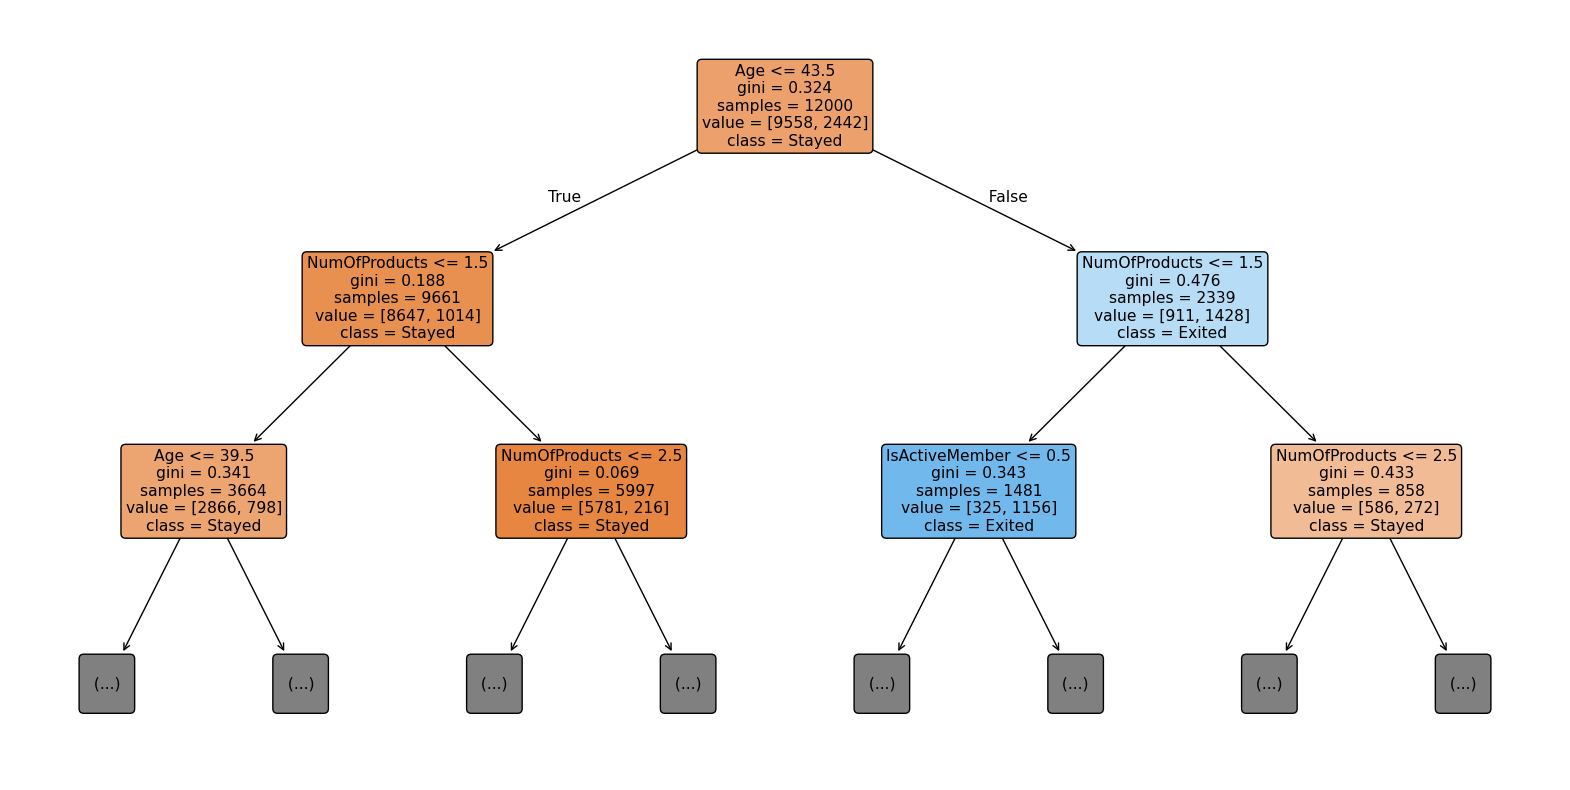

In [7]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X_train.columns,
    max_depth=2,
    filled=True,
    rounded=True,
    class_names=['Stayed', 'Exited'],
)
plt.show()

##**Які ознаки найвпливовіші на верхніх рівнях дерева?**

Корінь дерева розділяє за **`Age` (Вік) ≤ 43.5** - це найінформативніша ознака: молодші клієнти (≤43.5) значно рідше йдуть з банку (в лівій гілці частка `Exited=1` набагато нижча), ніж старші.

На другому рівні обидві гілки знову діляться за **`NumOfProducts` (кількість продуктів банку) ≤ 1.5** - тобто "має клієнт 1 продукт, чи 2+". Серед клієнтів з 1 продуктом імовірність відтоку суттєво вища, ніж серед тих, хто користується кількома продуктами (особливо помітно у старшій віковій групі: P(Exited=1) зростає до **~0.78**, коли `Age > 43.5` і `NumOfProducts ≤ 1`).

Отже, на верхніх рівнях дерево вважає **вік клієнта** і **кількість продуктів банку, якими він користується**, найсильнішими сигналами відтоку - це узгоджується з інтуїцією: старші клієнти з мінімальною залученістю (лише 1 продукт) - найризикованіша група.

In [8]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

importance_df.head(10)

,feature,importance
1,Age,0.356639
4,NumOfProducts,0.168379
7,EstimatedSalary,0.126598
0,CreditScore,0.122589
3,Balance,0.078428
2,Tenure,0.054646
6,IsActiveMember,0.033404
11,Gender_Male,0.017746
9,Geography_Germany,0.015110
5,HasCrCard,0.010435


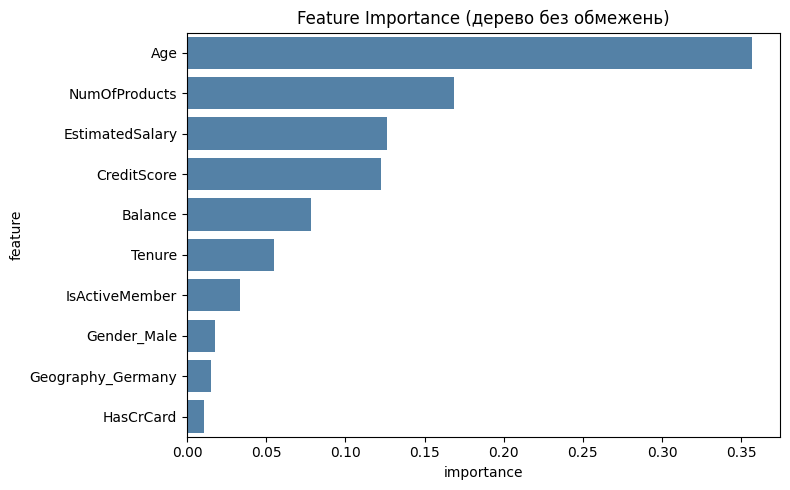

In [9]:
import seaborn as sns

plt.figure(figsize=(8, 5))
plt.title('Feature Importance (дерево без обмежень)')
sns.barplot(data=importance_df.head(10), x='importance', y='feature', color='steelblue')
plt.tight_layout()
plt.show()

# ЗАВДАННЯ 3

**Завдання 3**. Спробуйте знайти такі параметри моделі `DecisionTree` аби модель генералізувала ліпше (був вищий показник AUROC на валідаційній вибірці). Проекспериментуйте з різними значеннями параметрів `max_leaf_nodes`, `max_depth` та лишіть ті, які дають найкращий результат, разом з відповідними AUROC на тренувальній і валідаційній вибірках.

В цьому завданні спробуйте просто знайти параметри методом "тика" :)

### Теорія: `max_depth` і `max_leaf_nodes` як засоби боротьби з перенавчанням

Це **гіперпараметри** - значення, які ми задаємо вручну ДО навчання (на відміну від параметрів дерева - порогів і ознак для поділу, - які модель знаходить сама з даних).

- **`max_depth`** обмежує максимальну кількість рівнів "питань" від кореня до листка. Менше значення - простіше дерево, менше шансів підлаштуватися під шум, але й менше шансів вловити складні закономірності (**недотренування, underfitting**, якщо занадто мале). Більше значення - навпаки, ризик **перетренування (overfitting)**.
- **`max_leaf_nodes`** обмежує загальну кількість листків (фінальних передбачень), дозволяючи гілкам мати різну глибину - дерево "витрачає" бюджет листків на найкорисніші поділи, а не однаково на всі гілки.

Це типовий приклад **компромісу зсув-дисперсія (bias-variance tradeoff)**: занадто просте дерево має високий зсув (не вловлює закономірності), занадто складне - високу дисперсію (чутливе до шуму в конкретній тренувальній вибірці). Оптимум - десь посередині, і його шукають експериментально, порівнюючи AUROC на валідації для різних комбінацій.

In [10]:
results = []
for max_leaf_nodes in [8, 16, 24, 32, 48, 64, 96, 128]:
    for max_depth in [None, 5, 6, 7, 8]:
        model = DecisionTreeClassifier(max_leaf_nodes=max_leaf_nodes, max_depth=max_depth, random_state=42)
        model.fit(X_train, train_targets)
        train_auroc = roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1])
        val_auroc = roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1])
        results.append({
            'max_leaf_nodes': max_leaf_nodes,
            'max_depth': max_depth,
            'train_auroc': train_auroc,
            'val_auroc': val_auroc,
        })

results_df = pd.DataFrame(results).sort_values('val_auroc', ascending=False)
results_df.head(10)

,max_leaf_nodes,max_depth,train_auroc,val_auroc
20,48,NaN,0.930888,0.924750
29,64,8.0,0.933423,0.923911
23,48,7.0,0.930877,0.923787
24,48,8.0,0.930909,0.923311
17,32,6.0,0.927099,0.923027
22,48,6.0,0.932176,0.922050
16,32,5.0,0.925694,0.921927
21,48,5.0,0.925694,0.921927
26,64,5.0,0.925694,0.921927
31,96,5.0,0.925694,0.921927


##**ВИСНОВОК**

Найкращий результат на валідації дала комбінація `max_leaf_nodes` = 48 без обмеження `max_depth` (значення NaN означає, що глибину окремо не обмежували — дерево росте вглиб, доки не витратить весь бюджет у 48 листків): `train AUROC` ≈ 0.9309, `val AUROC` ~ 0.9248.

Це найкращий результат серед усіх перевірених комбінацій — навіть трохи кращий за фіксовані `max_depth`= 5-8 окремо (найближчий конкурент: `max_leaf_nodes`= 64, `max_depth`=8, де `val AUROC` ≈ 0.9239).

Судячи з таблиці, топові результати дають саме помірні значення `max_leaf_nodes` (32-64) у поєднанні або з відсутністю жорсткого обмеження глибини, або з max_depth у діапазоні 5-8 — усі вони дають дуже близькі `val AUROC` (0.919-0.925).

Порівняно з деревом без жодних обмежень (Завдання 2: `train AUROC` = 1.0, `val AUROC` ~ 0.77), різниця вражаюча: тут розрив між train і val становить лише ~ 0.006 (0.9309 проти 0.9248) замість ~ 0.23 — модель узагальнює набагато краще, майже не втрачаючи точності на нових даних.

Це показує, що `max_leaf_nodes` іноді дає трохи гнучкіший контроль за складністю дерева, ніж чистий `max_depth`: він дозволяє одним гілкам рости глибше (там, де це дійсно покращує розділення), а інші зупиняє раніше — і саме така нерівномірна структура тут виявилась ефективнішою.

#ЗАВДАННЯ 4

**Завдання 4**. В циклі пройдіться по значенням max_depth від 1 до 20 включно, на кожній ітерації натренуйте DecisionTree модель і виміряйте AUROC на трейн і валідаційних даних.

В кінці виведіть на графік залеєність між AUROC на трейн і валідаційних даних і номером ітерації.

### Теорія: крива навчання (learning/validation curve)

Графік залежності якості моделі від гіперпараметра (тут - `max_depth`) окремо для тренувальних і валідаційних даних називають **кривою валідації**. Це один із найкорисніших інструментів у машинному навчанні: він наочно показує три зони:

1. **Недотренування (underfitting)** - малий `max_depth`: обидві криві (train і val) низькі і близькі одна до одної - моделі бракує складності, щоб вловити закономірності.
2. **"Солодка точка" (sweet spot)** - AUROC на валідації **максимальний**, а розрив між train і val ще невеликий.
3. **Перетренування (overfitting)** - великий `max_depth`: AUROC на train продовжує зростати (аж до ~1.0), а AUROC на val починає падати - дерево підлаштовується під шум тренувальних даних замість загальних закономірностей.

In [11]:
depth_results = []
for max_depth in range(1, 21):
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, train_targets)
    train_auroc = roc_auc_score(train_targets, model.predict_proba(X_train)[:, 1])
    val_auroc = roc_auc_score(val_targets, model.predict_proba(X_val)[:, 1])
    depth_results.append({'max_depth': max_depth, 'train_auroc': train_auroc, 'val_auroc': val_auroc})

depth_df = pd.DataFrame(depth_results)
depth_df

,max_depth,train_auroc,val_auroc
0,1,0.744727,0.734865
1,2,0.842908,0.846496
2,3,0.897184,0.891146
3,4,0.911281,0.911264
4,5,0.925694,0.921927
5,6,0.933778,0.919789
6,7,0.941535,0.914449
7,8,0.949541,0.902598
8,9,0.959079,0.885731
9,10,0.969761,0.848573


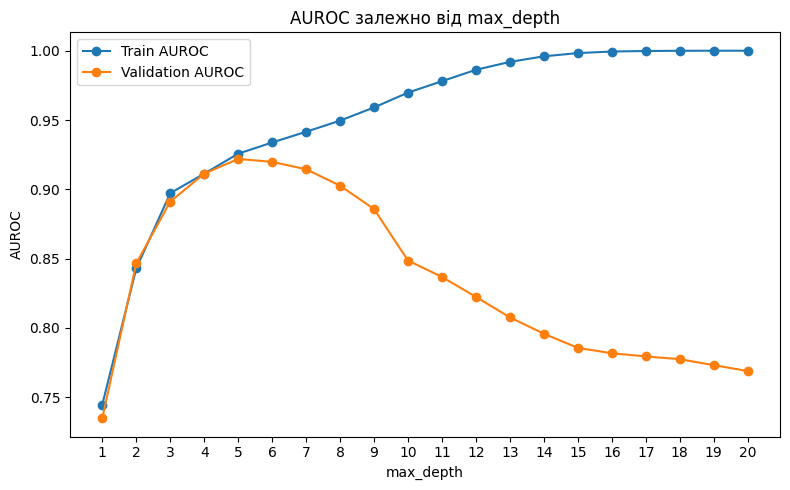

Найкращий max_depth за val_auroc: {'max_depth': 5.0, 'train_auroc': 0.9256944626530315, 'val_auroc': 0.9219267439467729}


In [16]:
plt.figure(figsize=(8, 5))
plt.plot(depth_df['max_depth'], depth_df['train_auroc'], marker='o', label='Train AUROC')
plt.plot(depth_df['max_depth'], depth_df['val_auroc'], marker='o', label='Validation AUROC')
plt.xlabel('max_depth')
plt.ylabel('AUROC')
plt.title('AUROC залежно від max_depth')
plt.xticks(range(1, 21))
plt.legend()
plt.tight_layout()
plt.show()

best_row = depth_df.loc[depth_df['val_auroc'].idxmax()] # idxmax() - знаходить мітку найбільшого числа стовбця
print('Найкращий max_depth за val_auroc:', best_row.to_dict())

##**ВИСНОВОК**

Графік чітко показує три зони, описані в теорії вище:

- При `max_depth` від 1 до ~ 4 обидві криві швидко зростають разом - модель ще недотренована.
- Максимум AUROC на валідації (**~ 0.9219**) досягається при **`max_depth = 5`**, після чого крива валідації починає повільно, а потім усе швидше падати.
- Після `max_depth ~ 9-10` розрив між train (прямує до 1.0) і val (падає до ~ 0.76) стає дуже великим - явне перетренування.

#ЗАВДАННЯ 5

**Завдання 5**.
1. Натренуйте модель `DecisionTree` з найкращим значенням `max_depth`, яке ви знайшли на попередній ітерації.
2. Завантажте тестові дані змагання з `test.csv`.
3. Зробіть попередню обробку даних з функцією `preprocess_new_data` з вашого модуля `process_bank_churn.py`.
4. Зробіть передбачення використовуючи цю модель на тестових даних змагання.
5. Сформуйте `submission.csv`.
6. Зробіть новий Submission на Kaggle і додайте тут скріншот Вашого скору на паблік лідерборді :)

### Теорія: чому фінальну модель тренують на ВСІХ даних

Під час пошуку найкращого `max_depth` валідаційний набір відіграв роль "чесного екзамену" - на ньому модель не навчалась, тому AUROC на val давав неупереджену оцінку якості. Але щойно найкращий гіперпараметр знайдено, тримати частину даних осторонь (у val) більше немає сенсу - навпаки, чим більше даних побачить модель, тим краще вона зможе вловити реальні закономірності.

Тому для **фінальної моделі**, яка піде на передбачення `test.csv` (і, відповідно, в Kaggle submission), ми навчаємо дерево з обраним `max_depth=5` на **об'єднаних train+val даних** (тобто на всьому `train.csv`). Валідаційна вибірка вже виконала свою роль - допомогла обрати гіперпараметр.

**Важливий нюанс щодо `encoder`/`scaler`.** `encoder`, який ми отримали з `preprocess_data()` на самому початку, був навчений (`fit`) лише на 80% даних (`train_df` після спліту) - а тепер ми хочемо тренувати модель на 100% даних (усьому `train.csv`). Використовувати старий `encoder` тут концептуально неправильно: якщо ми йдемо на full-даних, то й `encoder` (і `scaler`, якби ми його застосовували) має бачити ці full-дані під час навчання, а не лише 80% з них.

Тому ми НЕ викликаємо `preprocess_data()` повторно (вона завжди робить `train_test_split`, а нам розбиття вже не потрібне) і НЕ перевикористовуємо старий `encoder` через `preprocess_new_data`. Натомість напряму беремо "будівельні цеглинки" з `process_bank_churn.py` - `identify_numeric_categorical_cols` і `fit_encoder`/`apply_encoder` - і навчаємо новий `final_encoder` саме на full-даних. І лише ЦЕЙ `final_encoder` потім передаємо в `preprocess_new_data` для обробки `test.csv` - так, як і задумано завданням: `preprocess_new_data` використовується лише для нових даних, з об'єктами, навченими на найповнішому доступному наборі.

In [23]:
from process_bank_churn import identify_numeric_categorical_cols, fit_encoder, apply_encoder

best_max_depth = int(best_row['max_depth'])

full_inputs = raw_df[input_cols].copy()
full_targets = raw_df['Exited'].copy()

# Навчаємо НОВИЙ encoder саме на всіх 15000 рядках (а не перевикористовуємо
# encoder зі спліту, який бачив лише 80% даних)
numeric_cols, categorical_cols = identify_numeric_categorical_cols(full_inputs)
final_encoder = fit_encoder(full_inputs, categorical_cols)
X_full = apply_encoder(full_inputs, final_encoder, categorical_cols)
# scaler свідомо не використовуємо (scaler_numeric=False) - для дерева він не потрібен

final_model = DecisionTreeClassifier(max_depth=best_max_depth, random_state=42)
final_model.fit(X_full, full_targets)

print(f'Фінальна модель натренована з max_depth={best_max_depth} на {len(full_targets)} рядках train.csv')

Фінальна модель натренована з max_depth=5 на 15000 рядках train.csv


In [24]:
test_raw_df = pd.read_csv(test_csv)

# Тепер preprocess_new_data викликаємо з final_encoder (навченим на full-даних),
# а не зі старим encoder зі спліту
X_test = preprocess_new_data(test_raw_df, input_cols, None, final_encoder, scaler_numeric=False)
test_proba = final_model.predict_proba(X_test)[:, 1]

test_raw_df['Exited'] = test_proba
test_raw_df[['id', 'Exited']].head()

,id,Exited
0,15000,0.198454
1,15001,0.030877
2,15002,0.030877
3,15003,0.755319
4,15004,0.030877


In [25]:
sample_submission = pd.read_csv(sample_submission_csv)
sample_submission['Exited'] = sample_submission['id'].map(
    test_raw_df.set_index('id')['Exited']
)

print(sample_submission.shape)
print(sample_submission['Exited'].describe())
assert sample_submission['Exited'].isna().sum() == 0, 'Є пропущені передбачення!'

sample_submission.to_csv('submission_decision_tree.csv', index=False)
sample_submission.head()

(10000, 2)
count    10000.000000
mean         0.208156
std          0.293956
min          0.000000
25%          0.008689
50%          0.044958
75%          0.246914
max          1.000000
Name: Exited, dtype: float64


,id,Exited
0,15000,0.198454
1,15001,0.030877
2,15002,0.030877
3,15003,0.755319
4,15004,0.030877


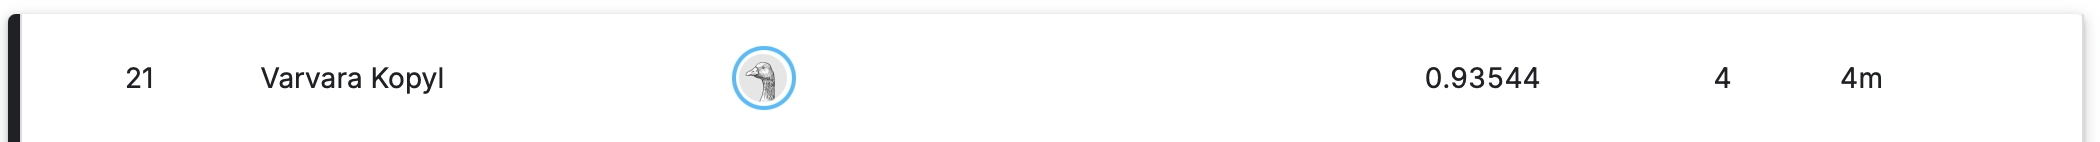